In [1]:
import pandas as pd
from occupancy.gridding import step_function_to_grid

occ = pd.read_parquet("../data/processed/occupancy.parquet")

grids = []
for sid, grp in occ.groupby("floorspaceid"):
    grp = grp.sort_values(["collecteddate", "id"])
    hc = step_function_to_grid(grp["collecteddate"], grp["headcount"], "15min")
    grids.append(hc.rename("headcount").to_frame().assign(space=sid[:8]))

long = pd.concat(grids).rename_axis("time").reset_index()
long.to_parquet("../data/processed/occupancy_15min.parquet")
print(long.shape)
long.groupby("space")["headcount"].describe()

(342386, 3)


,count,mean,std,min,25%,50%,75%,max
space,,,,,,,,
0f3f37f8,84573.0,0.497105,0.865708,0.0,0.0,0.100000,0.822222,24.935556
227f1068,74911.0,0.656549,1.311294,0.0,0.0,0.155556,0.842222,27.991111
3e5a14df,23415.0,1.311546,2.025779,0.0,0.0,0.673333,1.622222,26.628889
941f0352,84573.0,0.571976,0.892220,0.0,0.0,0.071111,0.968889,8.895556
cca1ac3e,74914.0,0.887365,2.285683,0.0,0.0,0.000000,1.000000,65.717778


In [2]:
from occupancy.features import add_time_features, add_lag_features

data = pd.read_parquet("../data/processed/occupancy_15min.parquet")
data = data.sort_values(["space", "time"])
data = add_time_features(data, time_col="time")
data = add_lag_features(data, group_col="space", value_col="headcount", lags=[1, 4, 96])

data["occupied"] = data["headcount"] > 0
data = data.dropna()   # drops the first day per space, where lag96 isn't available yet
print(data.shape)
data.head()

(341906, 12)


,time,headcount,space,local_hour,dow,is_weekend,hour_sin,hour_cos,headcount_lag1,headcount_lag4,headcount_lag96,occupied
96,2023-11-24 13:45:00+00:00,0.0,0f3f37f8,0.75,5,True,0.195090,0.980785,0.0,0.000000,0.0,False
97,2023-11-24 14:00:00+00:00,0.0,0f3f37f8,1.00,5,True,0.258819,0.965926,0.0,0.000000,0.0,False
98,2023-11-24 14:15:00+00:00,0.0,0f3f37f8,1.25,5,True,0.321439,0.946930,0.0,0.177778,0.0,False
99,2023-11-24 14:30:00+00:00,0.0,0f3f37f8,1.50,5,True,0.382683,0.923880,0.0,0.000000,0.0,False
100,2023-11-24 14:45:00+00:00,0.0,0f3f37f8,1.75,5,True,0.442289,0.896873,0.0,0.000000,0.0,False


In [3]:
cutoff = data["time"].quantile(0.8)
train = data[data["time"] < cutoff]
test = data[data["time"] >= cutoff]
print(cutoff)
print(train.shape, test.shape)
print(train["time"].min(), train["time"].max())
print(test["time"].min(), test["time"].max())

2025-10-26 10:45:00+00:00
(273523, 12) (68383, 12)
2023-11-24 13:45:00+00:00 2025-10-26 10:30:00+00:00
2025-10-26 10:45:00+00:00 2026-04-22 12:45:00+00:00


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:25s} MAE={mae:.3f}  RMSE={rmse:.3f}")

# baseline 1: persistence (last known value)
report("Persistence", test["headcount"], test["headcount_lag1"])

# baseline 2: mean by space, day-of-week, hour
profile = (
    train.groupby(["space", "dow", train["local_hour"].round(1)])["headcount"]
    .mean()
    .rename("profile_pred")
)
test_with_profile = test.join(profile, on=["space", "dow", test["local_hour"].round(1)])
report("Hour-of-week mean", test_with_profile["headcount"], test_with_profile["profile_pred"])

Persistence               MAE=0.211  RMSE=0.657
Hour-of-week mean         MAE=0.544  RMSE=1.151


In [7]:
from sklearn.tree import DecisionTreeRegressor
import time

features = ["hour_sin", "hour_cos", "dow", "is_weekend",
            "headcount_lag1", "headcount_lag4", "headcount_lag96"]

t0 = time.time()
tree_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=0)
tree_model.fit(train[features], train["headcount"])
tree_fit_time = time.time() - t0

t0 = time.time()
tree_pred = tree_model.predict(test[features])
tree_predict_time = time.time() - t0

report("Decision Tree", test["headcount"], tree_pred)
print(f"fit: {tree_fit_time:.3f}s  predict: {tree_predict_time:.3f}s")

Decision Tree             MAE=0.220  RMSE=0.643
fit: 1.044s  predict: 0.022s


In [8]:
from sklearn.linear_model import LinearRegression

t0 = time.time()
lin_model = LinearRegression()
lin_model.fit(train[features], train["headcount"])
lin_fit_time = time.time() - t0

t0 = time.time()
lin_pred = lin_model.predict(test[features])
lin_predict_time = time.time() - t0

report("Linear Regression", test["headcount"], lin_pred)
print(f"fit: {lin_fit_time:.3f}s  predict: {lin_predict_time:.3f}s")

Linear Regression         MAE=0.232  RMSE=0.633
fit: 0.115s  predict: 0.014s


In [9]:
import pandas as pd

results = pd.DataFrame([
    {"method": "Persistence", "MAE": mean_absolute_error(test["headcount"], test["headcount_lag1"])},
    {"method": "Hour-of-week mean", "MAE": mean_absolute_error(test_with_profile["headcount"], test_with_profile["profile_pred"])},
    {"method": "Decision Tree", "MAE": mean_absolute_error(test["headcount"], tree_pred), "fit_s": tree_fit_time, "predict_s": tree_predict_time},
    {"method": "Linear Regression", "MAE": mean_absolute_error(test["headcount"], lin_pred), "fit_s": lin_fit_time, "predict_s": lin_predict_time},
])
print(results)

# sensitivity: how does tree depth affect accuracy?
for depth in [2, 4, 6, 8, 12, None]:
    m = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=20, random_state=0)
    m.fit(train[features], train["headcount"])
    mae = mean_absolute_error(test["headcount"], m.predict(test[features]))
    print(f"max_depth={depth}: test MAE={mae:.3f}")

              method       MAE     fit_s  predict_s
0        Persistence  0.210560       NaN        NaN
1  Hour-of-week mean  0.543717       NaN        NaN
2      Decision Tree  0.220400  1.043911   0.021515
3  Linear Regression  0.232021  0.115285   0.014046
max_depth=2: test MAE=0.331
max_depth=4: test MAE=0.229
max_depth=6: test MAE=0.223
max_depth=8: test MAE=0.220
max_depth=12: test MAE=0.223
max_depth=None: test MAE=0.232


<Axes: xlabel='time'>

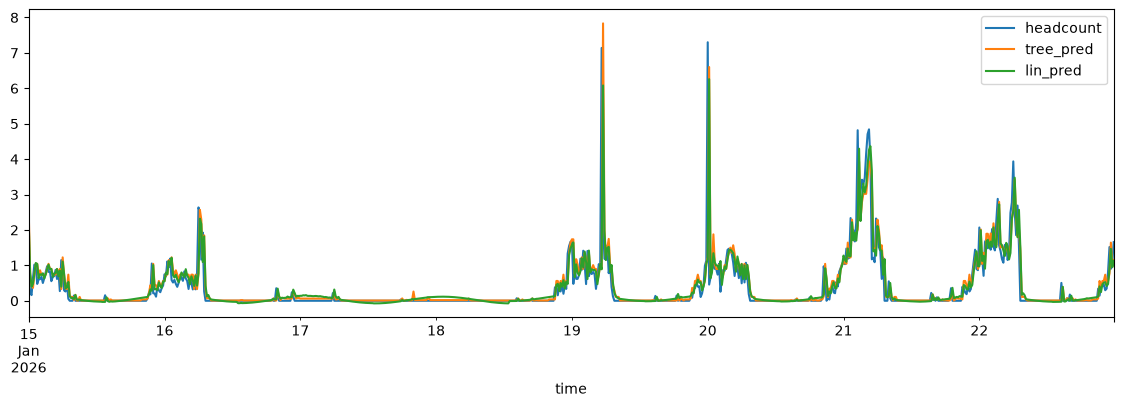

In [10]:
sid = test["space"].iloc[0]
sub = test[test["space"] == sid].copy()
sub["tree_pred"] = tree_model.predict(sub[features])
sub["lin_pred"] = lin_model.predict(sub[features])

sub.set_index("time")[["headcount", "tree_pred", "lin_pred"]].loc["2026-01-15":"2026-01-22"].plot(figsize=(14, 4))

In [11]:
print("cutoff:", cutoff)
print("test range:", test["time"].min(), "to", test["time"].max())

cutoff: 2025-10-26 10:45:00+00:00
test range: 2025-10-26 10:45:00+00:00 to 2026-04-22 12:45:00+00:00


In [13]:
horizons = {"15min": 1, "1hr": 4, "4hr": 16, "1day": 96}

results = []
for label, h in horizons.items():
    # shift the target itself forward by h bins, so "now" predicts h bins ahead
    target = data.groupby("space")["headcount"].shift(-h)
    valid = target.notna()

    X, y = data.loc[valid, features], target[valid]
    cutoff_h = data.loc[valid, "time"].quantile(0.8)
    is_train = data.loc[valid, "time"] < cutoff_h

    persist_mae = mean_absolute_error(y[~is_train], data.loc[valid, "headcount"][~is_train])

    tree = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=0)
    tree.fit(X[is_train], y[is_train])
    tree_mae = mean_absolute_error(y[~is_train], tree.predict(X[~is_train]))

    results.append({"horizon": label, "persistence_MAE": persist_mae, "tree_MAE": tree_mae})

pd.DataFrame(results)

,horizon,persistence_MAE,tree_MAE
0,15min,0.210560,0.297244
1,1hr,0.369869,0.390937
2,4hr,0.598849,0.510583
3,1day,0.528307,0.484020


In [14]:
results = []
for label, h in horizons.items():
    target = data.groupby("space")["headcount"].shift(-h)
    valid = target.notna()
    X, y = data.loc[valid, features], target[valid]
    cutoff_h = data.loc[valid, "time"].quantile(0.8)
    is_train = data.loc[valid, "time"] < cutoff_h

    persist_mae = mean_absolute_error(y[~is_train], data.loc[valid, "headcount"][~is_train])

    tree = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=0)
    tree.fit(X[is_train], y[is_train])
    tree_mae = mean_absolute_error(y[~is_train], tree.predict(X[~is_train]))

    lin = LinearRegression()
    lin.fit(X[is_train], y[is_train])
    lin_mae = mean_absolute_error(y[~is_train], lin.predict(X[~is_train]))

    results.append({
        "horizon": label, "n_rows": valid.sum(),
        "persistence_MAE": persist_mae, "tree_MAE": tree_mae, "linear_MAE": lin_mae,
    })

pd.DataFrame(results)

,horizon,n_rows,persistence_MAE,tree_MAE,linear_MAE
0,15min,341901,0.210560,0.297244,0.326222
1,1hr,341886,0.369869,0.390937,0.451873
2,4hr,341826,0.598849,0.510583,0.623672
3,1day,341426,0.528307,0.484020,0.564022


<Axes: title={'center': '4-hour-ahead prediction, normal week'}, xlabel='time'>

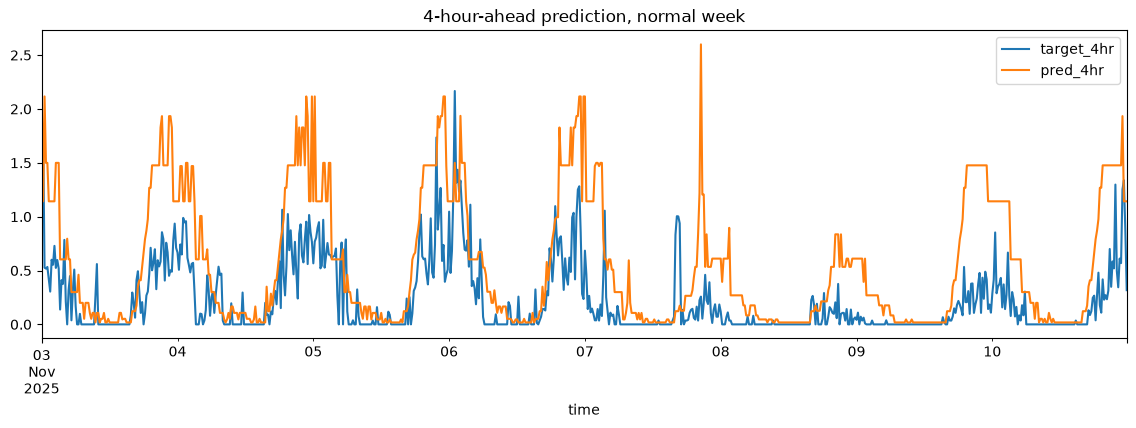

In [15]:
h = 16  # 4hr
target = data.groupby("space")["headcount"].shift(-h)
valid = target.notna()
X_all, y_all = data.loc[valid, features], target[valid]

tree_4hr = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=0)
tree_4hr.fit(X_all[data.loc[valid, "time"] < cutoff], y_all[data.loc[valid, "time"] < cutoff])

plot_data = data.loc[valid].copy()
plot_data["target_4hr"] = y_all
plot_data["pred_4hr"] = tree_4hr.predict(X_all)

sub = plot_data[(plot_data["space"] == plot_data["space"].iloc[0]) & (plot_data["time"] >= cutoff)]
sub.set_index("time")[["target_4hr", "pred_4hr"]].loc["2025-11-03":"2025-11-10"].plot(
    figsize=(14, 4), title="4-hour-ahead prediction, normal week"
)

In [1]:
import pandas as pd
from occupancy.features import add_time_features, add_lag_features, add_closure_flag

data = pd.read_parquet("../data/processed/occupancy_15min.parquet")
data = data.sort_values(["space", "time"])
data = add_time_features(data, time_col="time")
data = add_closure_flag(data, time_col="time")

lags = [1, 2, 4, 8, 16, 32, 96, 96 * 7]   # 15min,30min,1hr,2hr,4hr,8hr,1day,1week
data = add_lag_features(data, group_col="space", value_col="headcount", lags=lags)

data["roll_1hr"] = data.groupby("space")["headcount"].transform(
    lambda s: s.rolling(4, min_periods=1).mean()
)

data["occupied"] = data["headcount"] > 0
data = data.dropna()
print(data.shape)

(339026, 19)


In [2]:
data_enc = pd.get_dummies(data, columns=["space"], prefix="space")
space_cols = [c for c in data_enc.columns if c.startswith("space_")]

features = (
    ["hour_sin", "hour_cos", "dow", "is_weekend", "likely_closure", "roll_1hr"]
    + [f"headcount_lag{l}" for l in lags]
    + space_cols
)
print(len(features), "features")

19 features


In [3]:
cutoff = data_enc["time"].quantile(0.8)
train = data_enc[data_enc["time"] < cutoff]
test = data_enc[data_enc["time"] >= cutoff]
print(cutoff, train.shape, test.shape)

2025-10-27 22:45:00+00:00 (271219, 23) (67807, 23)


In [4]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor

param_grid = {"max_depth": [4, 6, 8, 10, 12], "min_samples_leaf": [5, 20, 50, 100]}
tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(
    DecisionTreeRegressor(random_state=0), param_grid,
    scoring="neg_mean_absolute_error", cv=tscv, n_jobs=-1,
)
search.fit(train[features], train["headcount"])
print(search.best_params_, -search.best_score_)

best_tree = search.best_estimator_

{'max_depth': 12, 'min_samples_leaf': 20} 0.20094805741980465


In [5]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

horizons = {"15min": 1, "1hr": 4, "4hr": 16, "1day": 96}
results = []

for label, h in horizons.items():
    target = data.groupby("space")["headcount"].shift(-h)   # shift on un-encoded data
    valid = target.notna()

    X = data_enc.loc[valid, features]
    y = target[valid]
    cutoff_h = data_enc.loc[valid, "time"].quantile(0.8)
    is_train = data_enc.loc[valid, "time"] < cutoff_h

    persist_mae = mean_absolute_error(y[~is_train], data.loc[valid, "headcount"][~is_train])

    tree = DecisionTreeRegressor(**search.best_params_, random_state=0)
    tree.fit(X[is_train], y[is_train])
    tree_mae = mean_absolute_error(y[~is_train], tree.predict(X[~is_train]))

    lin = LinearRegression()
    lin.fit(X[is_train], y[is_train])
    lin_mae = mean_absolute_error(y[~is_train], lin.predict(X[~is_train]))

    results.append({
        "horizon": label, "n_rows": int(valid.sum()),
        "persistence_MAE": persist_mae, "tree_MAE": tree_mae, "linear_MAE": lin_mae,
    })

pd.DataFrame(results)

,horizon,n_rows,persistence_MAE,tree_MAE,linear_MAE
0,15min,339021,0.210579,0.256250,0.273038
1,1hr,339006,0.369768,0.366706,0.423641
2,4hr,338946,0.598921,0.465910,0.606096
3,1day,338546,0.527902,0.465997,0.542477


In [2]:
import pandas as pd

occ = pd.read_parquet("../data/processed/occupancy.parquet")
print(occ.shape)

(9091732, 8)


In [3]:
from occupancy.gridding import step_function_to_grid, bin_staleness

grids = []
for sid, grp in occ.groupby("floorspaceid"):
    grp = grp.sort_values(["collecteddate", "id"])
    hc = step_function_to_grid(grp["collecteddate"], grp["headcount"], "15min")
    stale = bin_staleness(grp["collecteddate"], "15min", max_gap_hours=2.0)

    hc = hc.where(~stale)   # mask stale bins to NaN instead of holding the old value
    grids.append(hc.rename("headcount").to_frame().assign(space=sid[:8]))

long = pd.concat(grids).rename_axis("time").reset_index()
print("total rows:", len(long))
print("stale (now NaN):", long["headcount"].isna().sum(), f"({long['headcount'].isna().mean():.2%})")
long.to_parquet("../data/processed/occupancy_15min.parquet")

total rows: 342386
stale (now NaN): 72871 (21.28%)


In [5]:
from occupancy.features import add_time_features, add_lag_features, add_closure_flag

In [6]:
data = pd.read_parquet("../data/processed/occupancy_15min.parquet")
data = data.sort_values(["space", "time"])
data = add_time_features(data, time_col="time")
data = add_closure_flag(data, time_col="time")

lags = [1, 2, 4, 8, 16, 32, 96, 96 * 7]
data = add_lag_features(data, group_col="space", value_col="headcount", lags=lags)
data["roll_1hr"] = data.groupby("space")["headcount"].transform(
    lambda s: s.rolling(4, min_periods=1).mean()
)
data["occupied"] = data["headcount"] > 0
data = data.dropna()
print(data.shape)

data_enc = pd.get_dummies(data, columns=["space"], prefix="space")
space_cols = [c for c in data_enc.columns if c.startswith("space_")]
features = (
    ["hour_sin", "hour_cos", "dow", "is_weekend", "likely_closure", "roll_1hr"]
    + [f"headcount_lag{l}" for l in lags]
    + space_cols
)

cutoff = data_enc["time"].quantile(0.8)
train = data_enc[data_enc["time"] < cutoff]
test = data_enc[data_enc["time"] >= cutoff]

(155399, 19)


In [8]:
import pandas as pd
from occupancy.gridding import step_function_to_grid, bin_staleness
from occupancy.features import add_time_features, add_lag_features, add_closure_flag
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

occ = pd.read_parquet("../data/processed/occupancy.parquet")

In [9]:
grids = []
for sid, grp in occ.groupby("floorspaceid"):
    grp = grp.sort_values(["collecteddate", "id"])
    hc = step_function_to_grid(grp["collecteddate"], grp["headcount"], "15min")
    stale = bin_staleness(grp["collecteddate"], "15min", max_gap_hours=2.0)

    hc = hc.where(~stale)
    grids.append(hc.rename("headcount").to_frame().assign(space=sid[:8]))

long = pd.concat(grids).rename_axis("time").reset_index()
print("total rows:", len(long))
print("stale (now NaN):", long["headcount"].isna().sum(), f"({long['headcount'].isna().mean():.2%})")
long.to_parquet("../data/processed/occupancy_15min.parquet")

total rows: 342386
stale (now NaN): 72871 (21.28%)


In [10]:
data = pd.read_parquet("../data/processed/occupancy_15min.parquet")
data = data.sort_values(["space", "time"])
data = add_time_features(data, time_col="time")
data = add_closure_flag(data, time_col="time")

lags = [1, 2, 4, 8, 16, 32, 96, 96 * 7]
data = add_lag_features(data, group_col="space", value_col="headcount", lags=lags)
data["roll_1hr"] = data.groupby("space")["headcount"].transform(
    lambda s: s.rolling(4, min_periods=1).mean()
)
data["occupied"] = data["headcount"] > 0
data = data.dropna()
print(data.shape)

(155399, 19)


In [11]:
data_enc = pd.get_dummies(data, columns=["space"], prefix="space")
space_cols = [c for c in data_enc.columns if c.startswith("space_")]
features = (
    ["hour_sin", "hour_cos", "dow", "is_weekend", "likely_closure", "roll_1hr"]
    + [f"headcount_lag{l}" for l in lags]
    + space_cols
)

cutoff = data_enc["time"].quantile(0.8)
train = data_enc[data_enc["time"] < cutoff]
test = data_enc[data_enc["time"] >= cutoff]
print(cutoff, train.shape, test.shape)

2025-10-09 19:45:00+00:00 (124317, 23) (31082, 23)


In [12]:
param_grid = {"max_depth": [4, 6, 8, 10, 12], "min_samples_leaf": [5, 20, 50, 100]}
tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(
    DecisionTreeRegressor(random_state=0), param_grid,
    scoring="neg_mean_absolute_error", cv=tscv, n_jobs=-1,
)
search.fit(train[features], train["headcount"])
print(search.best_params_, -search.best_score_)

best_tree = search.best_estimator_

{'max_depth': 12, 'min_samples_leaf': 20} 0.289187083451245


In [13]:
horizons = {"15min": 1, "1hr": 4, "4hr": 16, "1day": 96}
results = []

for label, h in horizons.items():
    target = data.groupby("space")["headcount"].shift(-h)
    valid = target.notna()

    X = data_enc.loc[valid, features]
    y = target[valid]
    cutoff_h = data_enc.loc[valid, "time"].quantile(0.8)
    is_train = data_enc.loc[valid, "time"] < cutoff_h

    persist_mae = mean_absolute_error(y[~is_train], data.loc[valid, "headcount"][~is_train])

    tree = DecisionTreeRegressor(**search.best_params_, random_state=0)
    tree.fit(X[is_train], y[is_train])
    tree_mae = mean_absolute_error(y[~is_train], tree.predict(X[~is_train]))

    lin = LinearRegression()
    lin.fit(X[is_train], y[is_train])
    lin_mae = mean_absolute_error(y[~is_train], lin.predict(X[~is_train]))

    results.append({
        "horizon": label, "n_rows": int(valid.sum()),
        "persistence_MAE": persist_mae, "tree_MAE": tree_mae, "linear_MAE": lin_mae,
    })

pd.DataFrame(results)

,horizon,n_rows,persistence_MAE,tree_MAE,linear_MAE
0,15min,155394,0.337345,0.418842,0.403202
1,1hr,155379,0.615300,0.608795,0.622487
2,4hr,155319,0.935278,0.776869,0.817181
3,1day,154919,0.949891,0.827841,0.814007


In [14]:
for max_gap in [2, 4, 8, 24]:
    grids = []
    for sid, grp in occ.groupby("floorspaceid"):
        grp = grp.sort_values(["collecteddate", "id"])
        hc = step_function_to_grid(grp["collecteddate"], grp["headcount"], "15min")
        stale = bin_staleness(grp["collecteddate"], "15min", max_gap_hours=max_gap)
        hc = hc.where(~stale)
        grids.append(hc.rename("headcount").to_frame().assign(space=sid[:8]))
    tmp = pd.concat(grids)
    print(f"max_gap={max_gap}hr: {tmp['headcount'].isna().mean():.1%} masked")

max_gap=2hr: 21.3% masked
max_gap=4hr: 13.4% masked
max_gap=8hr: 5.9% masked
max_gap=24hr: 1.2% masked


In [3]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor

train = encoded[encoded["time"] < encoded["time"].quantile(0.8)]

param_grid = {"max_depth": [4, 6, 8, 10, 12], "min_samples_leaf": [5, 20, 50, 100]}
tscv = TimeSeriesSplit(n_splits=5)
search = GridSearchCV(
    DecisionTreeRegressor(random_state=0), param_grid,
    scoring="neg_mean_absolute_error", cv=tscv, n_jobs=-1,
)
search.fit(train[feature_cols], train["headcount"])
print(search.best_params_)

{'max_depth': 12, 'min_samples_leaf': 20}


In [4]:
import pandas as pd
from occupancy.features import build_features
from occupancy.evaluate import compare_at_horizon
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

grid = pd.read_parquet("../data/processed/occupancy_15min.parquet")
encoded, feature_cols = build_features(grid, lags=[1, 2, 4, 8, 16, 32, 96, 96*7])
print(encoded.shape, len(feature_cols))

horizons = {"15min": 1, "1hr": 4, "4hr": 16, "1day": 96}
results = []
for label, h in horizons.items():
    r = compare_at_horizon(
        encoded, encoded, feature_cols,
        models={
            "tree": DecisionTreeRegressor(**search.best_params_, random_state=0),
            "linear": LinearRegression(),
        },
        horizon_bins=h,
    )
    results.append({"horizon": label, **r})
pd.DataFrame(results)

(155399, 23) 19


KeyError: 'space'